<a href="https://colab.research.google.com/github/khushi-2003/AI-projects/blob/main/MobilePricePrediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mobile Price Prediction Model using ANN.

Step 1 - Data import

In [2]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/khushi-2003/Datasets/refs/heads/main/mobile_train%20(1).csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:
df.shape

(2000, 21)

In [5]:
df.duplicated().sum()

np.int64(0)

Step 2 - Seperate x and y features.

  y : price_range

  0 : cheap
  1: moderate
  2: Mid range
  3: Expensive

In [6]:
x = df.drop(columns='price_range')
y = df[['price_range']]

In [7]:
x.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [8]:
y.head()

,price_range
0,1
1,2
2,2
3,2
4,1


Step 3 - Feature Engineering


In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = make_pipeline(
    SimpleImputer(strategy = 'mean'),
    StandardScaler()
).set_output(transform='pandas')

In [10]:
x_pre = num_pipe.fit_transform(x)
x_pre.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099


In [11]:
y['price_range'].unique()

array([1, 2, 3, 0])

Step 4 - Split training and testing data


In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_pre,y,train_size=0.75,random_state=21)

Multiclass classification : Y feature has multi classes ranging from 0-3. Hence, performing one-hot encoding.



In [13]:
from keras.utils import to_categorical
ytrain_cat = to_categorical(y_train)
ytest_cat = to_categorical(y_test)

In [14]:
ytrain_cat[:10]

array([[0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.]])

Step 5 - Model Building

In [15]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import EarlyStopping

#initialise the model
model = Sequential()

#input layer
model.add(Input(shape=(x_train.shape[1],)))

#add the hidden layer 1
model.add(Dense(units=32,activation='relu'))

#add dropout
model.add(Dropout(rate=0.3))

# Hidden layer2
model.add(Dense(units=16,activation='relu'))

#Dropout layer
model.add(Dropout(rate=0.15))

#Output layer
model.add(Dense(units=ytrain_cat.shape[1],activation='softmax'))

In [16]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics =['accuracy'])

In [17]:
es = EarlyStopping(monitor='val_loss',patience=10)

In [18]:
nn=model.fit(x_train,ytrain_cat,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.2742 - loss: 1.4816 - val_accuracy: 0.2467 - val_loss: 1.4308
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2767 - loss: 1.4104 - val_accuracy: 0.2867 - val_loss: 1.3823
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3375 - loss: 1.3503 - val_accuracy: 0.3600 - val_loss: 1.3385
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3775 - loss: 1.3131 - val_accuracy: 0.3967 - val_loss: 1.2931
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4042 - loss: 1.2511 - val_accuracy: 0.4433 - val_loss: 1.2306
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4642 - loss: 1.1858 - val_accuracy: 0.4967 - val_loss: 1.1502
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5017 - loss: 1.1137 - val_accuracy: 0.5133 - val_loss: 1.0612
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5333 - loss: 1.0387 - val_accuracy: 0.5667 

Step 6 - Learning curve

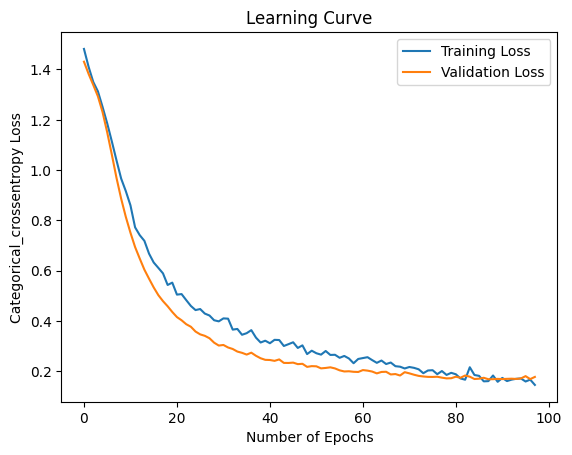

In [19]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Categorical_crossentropy Loss")
plt.legend()
plt.show()

Step 7 - Model Evaluation

In [20]:
model.evaluate(x_train,ytrain_cat)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9793 - loss: 0.0739


[0.07388573884963989, 0.9793333411216736]

In [21]:
model.evaluate(x_test,ytest_cat)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9160 - loss: 0.1917


[0.19170154631137848, 0.9160000085830688]

Confusion matrix and Classification report

In [22]:
yprobs = model.predict(x_test)
yprobs[:5]


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


array([[4.2756505e-26, 1.1483805e-07, 1.6760227e-01, 8.3239764e-01],
       [9.9615657e-01, 3.8434272e-03, 4.9828813e-12, 6.4020422e-40],
       [5.5572110e-01, 4.4427678e-01, 2.0497080e-06, 1.8166273e-24],
       [9.9962378e-01, 3.7616544e-04, 1.0743028e-15, 0.0000000e+00],
       [7.1466222e-44, 4.9961581e-14, 1.5214622e-03, 9.9847859e-01]],
      dtype=float32)

In [23]:
yprobs[0]

array([4.2756505e-26, 1.1483805e-07, 1.6760227e-01, 8.3239764e-01],
      dtype=float32)

In [24]:
import numpy as np
np.argmax(yprobs[0]) # give me the position of max value in yprobs[0] array



np.int64(3)

In [25]:
import numpy as np
ypreds = []
for i in yprobs:
  pos = np.argmax(i)
  ypreds.append(pos)
ypreds

[np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(3),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(2),
 np.int64(3),
 np.int64(0),
 np.int64(3),
 np.int64(3),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(2),
 np.int64(1),
 np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.in

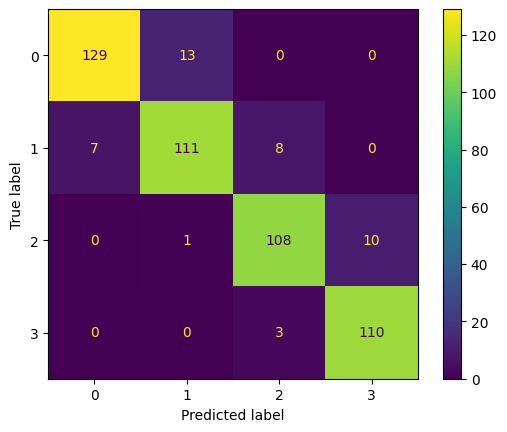

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_predictions(y_test,ypreds)

In [28]:
print(classification_report(y_test,ypreds))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       142
           1       0.89      0.88      0.88       126
           2       0.91      0.91      0.91       119
           3       0.92      0.97      0.94       113

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



Model is providing an accuracy of 92% in testing. We can consider this model for final predictions

In [29]:
model.save("MobilePredictions.keras")

In [30]:
from keras.models import load_model
m1 = load_model("/content/MobilePredictions.keras")
m1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,806 (14.87 KB)

 Trainable params: 1,268 (4.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,538 (9.92 KB)